# Data Cleaning & Exploratory Analysis
**Group 29** | CDC BRFSS 2011-2024

Uses all tools from the proposal: pandas, matplotlib, seaborn, plotly, altair.
This notebook complements the Streamlit dashboard.

In [11]:
# Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/brfss_features.csv")
df["YearStart"] = df["YearStart"].astype(int)
tot = df[df["StratificationCategory1"] == "Total"]
print(f"Loaded: {df.shape[0]:,} rows")

Loaded: 18,112 rows


## 1. Data Cleaning Steps

Details in `pipeline.py` and `01_data_cleaning.ipynb`. Summary:
- 5 columns dropped (95%+ missing)
- 8,064 non-state rows removed
- European decimal format (34,8 -> 34.8)
- 10,226 suppressed values flagged, 3,478 interpolated
- Stratification labels normalized

## 2. Seaborn: Correlation Heatmap

Seaborn was used in the proposal for static heatmaps.

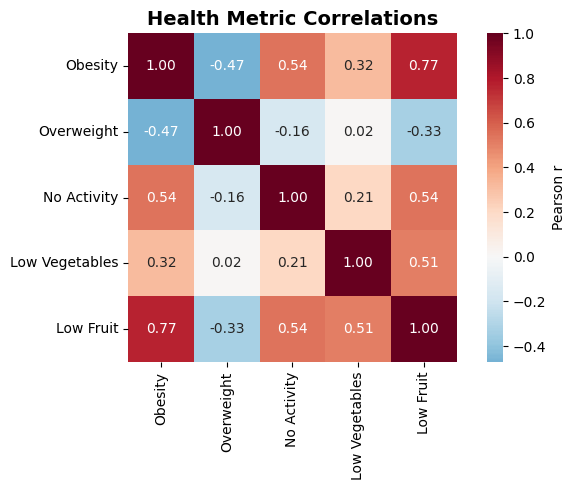

In [12]:
# Seaborn heatmap: static, print-ready
corr = tot[["obesity_rate","overweight_rate","pa_none_rate","vegetables_less1_rate","fruit_less1_rate"]].corr()
labels = ["Obesity","Overweight","No Activity","Low Vegetables","Low Fruit"]
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            xticklabels=labels, yticklabels=labels, square=True,
            cbar_kws={"label":"Pearson r"})
plt.title("Health Metric Correlations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/seaborn_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Matplotlib: Obesity Trend by Region

Matplotlib was used for custom-formatted line charts with annotations.

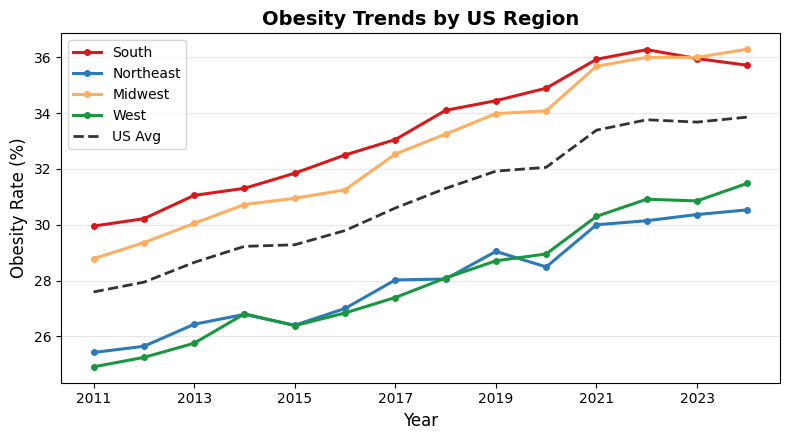

In [13]:
# Matplotlib: regional trend with shaded range
regions = ["South","Northeast","Midwest","West"]
colors = ["#d7191c","#2c7bb6","#fdae61","#1a9641"]
fig, ax = plt.subplots(figsize=(8,4.5))
for reg, c in zip(regions, colors):
    data = tot[tot["region"]==reg].groupby("YearStart")["obesity_rate"].mean()
    ax.plot(data.index, data.values, color=c, linewidth=2.2, label=reg, marker="o", markersize=4)
natl = tot.groupby("YearStart")["obesity_rate"].mean()
ax.plot(natl.index, natl.values, color="#333", linewidth=2, linestyle="--", label="US Avg")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Obesity Rate (%)", fontsize=12)
ax.set_title("Obesity Trends by US Region", fontsize=14, fontweight="bold")
ax.legend(frameon=True, fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_xticks(range(2011,2025,2))
fig.tight_layout()
fig.savefig("../data/matplotlib_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Altair: Interactive Obesity by Income

Altair was used for interactive declarative charts (Vega-Lite backend).

## income_level
Proposal §5 specifies `income_level` as `Low / Medium / High`. We map the six raw CDC income brackets to these three categories. Rows from other stratification dimensions (Sex, Age, etc.) remain NaN — expected behaviour.

In [14]:
income_map = {
    "Less than $15,000":  "Low",
    "$15,000 - $24,999":  "Low",
    "$25,000 - $34,999":  "Medium",
    "$35,000 - $49,999":  "Medium",
    "$50,000 - $74,999":  "High",
    "$75,000 or greater": "High",
}
df["income_level"] = df["Stratification1"].map(income_map)

# Sanity check: only Income rows should be non-null
assert df[df["StratificationCategory1"] != "Income"]["income_level"].isna().all()
print(df[df["StratificationCategory1"] == "Income"]["income_level"].value_counts().to_string())

income_level
Low       1428
Medium    1428
High      1428


In [15]:
# Altair: interactive bar chart coloured by income_level
import altair as alt
inc_data = df[(df["StratificationCategory1"]=="Income")&(df["YearStart"]==df["YearStart"].max())]
inc_data = inc_data.dropna(subset=["obesity_rate", "income_level"])
inc_order = ["Less than $15,000","$15,000 - $24,999","$25,000 - $34,999",
             "$35,000 - $49,999","$50,000 - $74,999","$75,000 or greater"]
level_colors = alt.Scale(domain=["Low","Medium","High"], range=["#d7191c","#fdae61","#1a9641"])
chart = alt.Chart(inc_data[inc_data["Stratification1"].isin(inc_order)]).mark_bar().encode(
    x=alt.X("mean(obesity_rate):Q", title="Mean Obesity Rate (%)", scale=alt.Scale(domain=[20,45])),
    y=alt.Y("Stratification1:N", title=None, sort=inc_order),
    color=alt.Color("income_level:N", scale=level_colors, title="Income Level"),
    tooltip=["Stratification1", "income_level", "mean(obesity_rate)"]
).properties(width=600, height=300, title="Obesity by Income Level (2024)")
chart.save("../data/altair_income.json")
chart

alt.Chart(...)

## 5. Summary

| Tool | Use in Project |
|------|---------------|
| pandas | Data loading, cleaning, aggregation, feature engineering |
| matplotlib | Static line chart with annotations, export-quality figures |
| seaborn | Correlation heatmap for print-ready output |
| plotly | All interactive charts in Streamlit dashboard |
| altair | Declarative interactive bar chart |
| Streamlit | Full dashboard integration |
| Jupyter | This notebook and the cleaning notebook |